## 📚 Import Required Libraries

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style (with fallback for compatibility)
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("📚 All libraries imported successfully!")
print("🔄 Proceeding with data loading...")

📚 All libraries imported successfully!
🔄 Proceeding with data loading...


## 🔄 Automatic Data Loading

Based on your configuration, this will automatically load your evaluation data and determine whether to show single-run analysis or comparison.

In [5]:
# Data extraction function (same as before)
def extract_metrics_data(data):
    """
    Extract metrics data from the DeepEval JSON structure
    """
    metrics_list = []
    
    for test_case_key, test_case_data in data['test_cases_lookup_map'].items():
        # Parse the test case key to extract input and expected output
        test_case_info = json.loads(test_case_key)
        
        # Extract metrics from cached_metrics_data
        for metric in test_case_data['cached_metrics_data']:
            metric_data = metric['metric_data']
            
            metrics_list.append({
                'input': test_case_info.get('input', ''),
                'actual_output': test_case_info.get('actual_output', ''),
                'expected_output': test_case_info.get('expected_output', ''),
                'metric_name': metric_data['name'],
                'score': metric_data['score'],
                'threshold': metric_data['threshold'],
                'success': metric_data['success'],
                'reason': metric_data.get('reason', ''),
                'evaluation_model': metric_data.get('evaluationModel', ''),
                'evaluation_cost': metric_data.get('evaluationCost', 0)
            })
    
    return pd.DataFrame(metrics_list)

# Automatic data loading based on configuration
print("🔄 Loading evaluation data based on your configuration...")
print("="*60)

# Load primary file (always required)
try:
    file_path = Path(file1)  # Keep this for compatibility with later cells
    with open(file1, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = extract_metrics_data(data)
    
    # Extract run ID for single-run analysis
    if file_path.parent.name.startswith('run_'):
        run_id = file_path.parent.name
    else:
        run_id = file_path.stem.replace('.deepeval-cache_', '').replace('-', '_')
    
    print(f"✅ Primary file loaded: {len(df)} evaluations from {file1}")
    print(f"📊 Metrics found: {list(df['metric_name'].unique())}")
    
except Exception as e:
    print(f"❌ Error loading primary file {file1}: {e}")
    print("💡 Please check the file path in the configuration cell above.")
    df = None

# Handle comparison mode vs single-run mode
if file2 is not None:
    print(f"\n🔄 Comparison mode: Loading second file...")
    
    # Use the comparison function
    def compare_two_runs(file1_path, file2_path, run1_name=None, run2_name=None):
        """Compare two DeepEval cache files directly"""
        
        # Load first file
        try:
            with open(file1_path, 'r', encoding='utf-8') as f:
                data1 = json.load(f)
            df1 = extract_metrics_data(data1)
            run1_id = run1_name or Path(file1_path).parent.name or "Run 1"
            df1['run_id'] = run1_id
        except Exception as e:
            print(f"❌ Error loading {file1_path}: {e}")
            return None
        
        # Load second file
        try:
            with open(file2_path, 'r', encoding='utf-8') as f:
                data2 = json.load(f)
            df2 = extract_metrics_data(data2)
            run2_id = run2_name or Path(file2_path).parent.name or "Run 2"
            df2['run_id'] = run2_id
        except Exception as e:
            print(f"❌ Error loading {file2_path}: {e}")
            return None
        
        # Combine data
        combined_df = pd.concat([df1, df2], ignore_index=True)
        return combined_df, run1_id, run2_id
    
    # Load comparison data
    comparison_data = compare_two_runs(file1, file2, run1_name, run2_name)
    
    if comparison_data is not None:
        multi_run_df, run1_id, run2_id = comparison_data
        comparison_mode = True
        print(f"✅ Second file loaded: {len(multi_run_df[multi_run_df['run_id'] == run2_id])} evaluations from {file2}")
        print(f"🎯 Comparison ready: '{run1_id}' vs '{run2_id}'")
        print(f"📊 Total evaluations: {len(multi_run_df)}")
    else:
        print("❌ Could not load comparison data. Falling back to single-run mode.")
        comparison_mode = False
        multi_run_df = None
else:
    print(f"\n📊 Single-run mode: Analyzing {file1}")
    comparison_mode = False
    multi_run_df = None

print("="*60)
if comparison_mode:
    print("🎉 READY FOR COMPARISON ANALYSIS!")
    print("📋 The following sections will show side-by-side comparisons")
    print("💡 All single-run visualizations will also be available for the primary file")
else:
    print("🎉 READY FOR SINGLE-RUN ANALYSIS!")
    print("📋 The following sections will show comprehensive analysis of your evaluation")
    print("💡 To enable comparison mode, set file2 in the configuration cell above")
print("="*60)

🔄 Loading evaluation data based on your configuration...
✅ Primary file loaded: 150 evaluations from .deepeval/run_20250717_2103/.deepeval-cache_20250717_2103.json
📊 Metrics found: ['Factual Correctness [GEval]', 'Answer Relevancy', 'Faithfulness']

🔄 Comparison mode: Loading second file...
✅ Second file loaded: 30 evaluations from .deepeval/run_20250723_1409/.deepeval-cache_20250723_1409.json
🎯 Comparison ready: 'run_20250717_2103' vs 'run_20250723_1409'
📊 Total evaluations: 180
🎉 READY FOR COMPARISON ANALYSIS!
📋 The following sections will show side-by-side comparisons
💡 All single-run visualizations will also be available for the primary file


## 2. Overview Dashboard

In [6]:
# Create a comprehensive dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Score Distribution by Metric',
        'Success Rate by Metric', 
        'Score vs Threshold Comparison',
        'Detailed Score Analysis'
    ),
    specs=[[{"type": "box"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "violin"}]]
)

# 1. Box plot of scores by metric
for i, metric in enumerate(df['metric_name'].unique()):
    metric_data = df[df['metric_name'] == metric]
    fig.add_trace(
        go.Box(
            y=metric_data['score'],
            name=metric,
            boxpoints='outliers'
        ),
        row=1, col=1
    )

# 2. Success rate bar chart
success_summary = df.groupby('metric_name')['success'].mean().reset_index()
fig.add_trace(
    go.Bar(
        x=success_summary['metric_name'],
        y=success_summary['success'],
        text=[f"{val:.1%}" for val in success_summary['success']],
        textposition='auto',
        name='Success Rate'
    ),
    row=1, col=2
)

# 3. Score vs Threshold scatter
colors = px.colors.qualitative.Set1
for i, metric in enumerate(df['metric_name'].unique()):
    metric_data = df[df['metric_name'] == metric]
    fig.add_trace(
        go.Scatter(
            x=metric_data['threshold'],
            y=metric_data['score'],
            mode='markers',
            name=metric,
            marker=dict(
                color=colors[i % len(colors)],
                size=8,
                symbol=['circle' if success else 'x' for success in metric_data['success']]
            ),
            text=[f"Success: {success}" for success in metric_data['success']],
            hovertemplate='<b>%{fullData.name}</b><br>Score: %{y:.3f}<br>Threshold: %{x:.3f}<br>%{text}<extra></extra>'
        ),
        row=2, col=1
    )

# 4. Violin plot for detailed distribution
for i, metric in enumerate(df['metric_name'].unique()):
    metric_data = df[df['metric_name'] == metric]
    fig.add_trace(
        go.Violin(
            y=metric_data['score'],
            name=metric,
            box_visible=True,
            meanline_visible=True
        ),
        row=2, col=2
    )

# Update layout
fig.update_layout(
    height=800,
    title_text="DeepEval Metrics Dashboard",
    title_x=0.5,
    showlegend=False
)

# Update y-axes labels
fig.update_yaxes(title_text="Score", row=1, col=1)
fig.update_yaxes(title_text="Success Rate", row=1, col=2)
fig.update_yaxes(title_text="Score", row=2, col=1)
fig.update_yaxes(title_text="Score", row=2, col=2)

# Update x-axes labels  
fig.update_xaxes(title_text="Metric", row=1, col=1)
fig.update_xaxes(title_text="Metric", row=1, col=2)
fig.update_xaxes(title_text="Threshold", row=2, col=1)
fig.update_xaxes(title_text="Metric", row=2, col=2)

fig.show()

## 3. Detailed Metric Analysis

In [7]:
# Detailed statistics for each metric
print("=== DETAILED METRIC STATISTICS ===")

for metric in df['metric_name'].unique():
    metric_data = df[df['metric_name'] == metric]
    
    print(f"\n📊 {metric}")
    print(f"   Evaluations: {len(metric_data)}")
    print(f"   Success Rate: {metric_data['success'].mean():.1%}")
    print(f"   Average Score: {metric_data['score'].mean():.3f}")
    print(f"   Score Range: {metric_data['score'].min():.3f} - {metric_data['score'].max():.3f}")
    print(f"   Threshold: {metric_data['threshold'].iloc[0]:.3f}")
    print(f"   Std Deviation: {metric_data['score'].std():.3f}")
    
    # Show failures if any
    failures = metric_data[~metric_data['success']]
    if len(failures) > 0:
        print(f"   ❌ Failures: {len(failures)} ({len(failures)/len(metric_data):.1%})")
        print(f"   Average Failure Score: {failures['score'].mean():.3f}")

=== DETAILED METRIC STATISTICS ===

📊 Factual Correctness [GEval]
   Evaluations: 50
   Success Rate: 44.0%
   Average Score: 0.435
   Score Range: 0.000 - 0.908
   Threshold: 0.500
   Std Deviation: 0.361
   ❌ Failures: 28 (56.0%)
   Average Failure Score: 0.129

📊 Answer Relevancy
   Evaluations: 50
   Success Rate: 72.0%
   Average Score: 0.790
   Score Range: 0.000 - 1.000
   Threshold: 0.700
   Std Deviation: 0.313
   ❌ Failures: 14 (28.0%)
   Average Failure Score: 0.338

📊 Faithfulness
   Evaluations: 50
   Success Rate: 80.0%
   Average Score: 0.821
   Score Range: 0.250 - 1.000
   Threshold: 0.600
   Std Deviation: 0.227
   ❌ Failures: 10 (20.0%)
   Average Failure Score: 0.433


## 4. Score Distribution Analysis

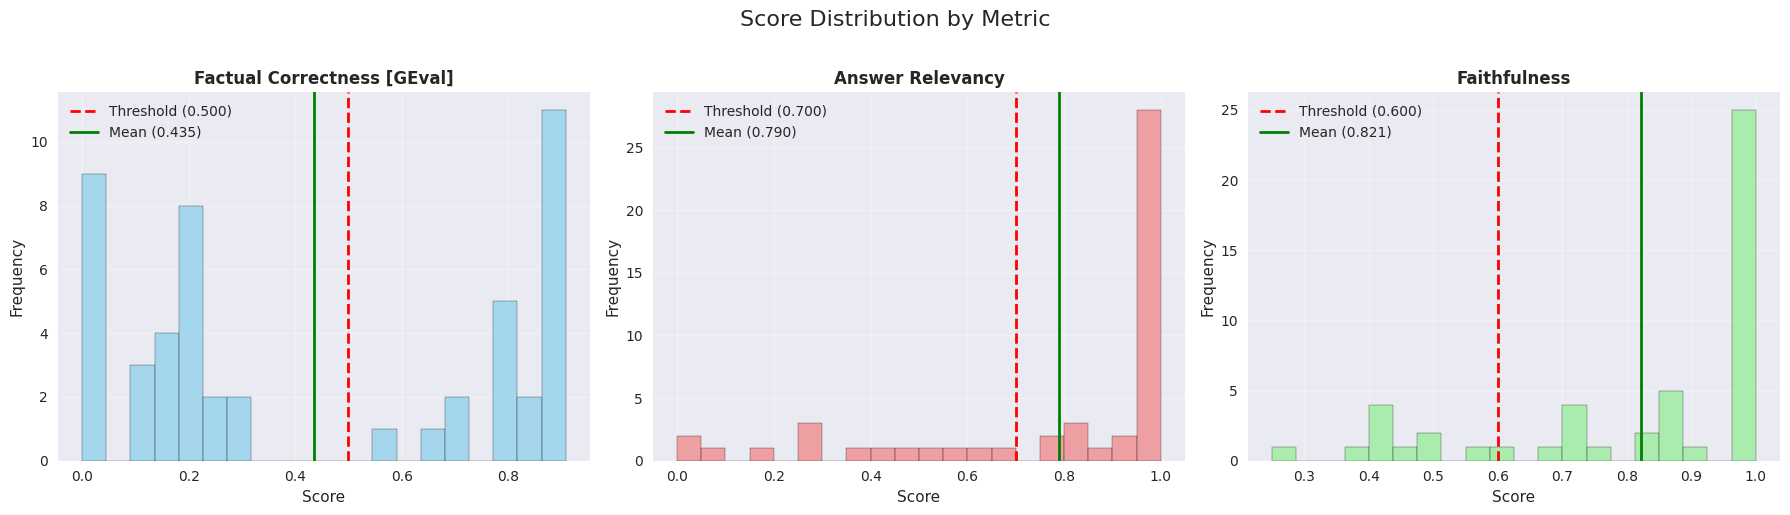

In [8]:
# Create histograms for each metric
metrics = df['metric_name'].unique()
n_metrics = len(metrics)

# Adjust figure size and layout based on number of metrics
fig, axes = plt.subplots(1, n_metrics, figsize=(6*n_metrics, 5))
if n_metrics == 1:
    axes = [axes]  # Make it iterable for single metric
    
fig.suptitle('Score Distribution by Metric', fontsize=16, y=1.02)

colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple']  # Extended color list

for i, metric in enumerate(metrics):
    metric_data = df[df['metric_name'] == metric]
    
    # Histogram
    axes[i].hist(metric_data['score'], bins=20, alpha=0.7, 
                color=colors[i % len(colors)], edgecolor='black')
    
    # Add threshold line
    threshold = metric_data['threshold'].iloc[0]
    axes[i].axvline(threshold, color='red', linestyle='--', linewidth=2, 
                   label=f'Threshold ({threshold:.3f})')
    
    # Add mean line
    mean_score = metric_data['score'].mean()
    axes[i].axvline(mean_score, color='green', linestyle='-', linewidth=2, 
                   label=f'Mean ({mean_score:.3f})')
    
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Pass/Fail Analysis

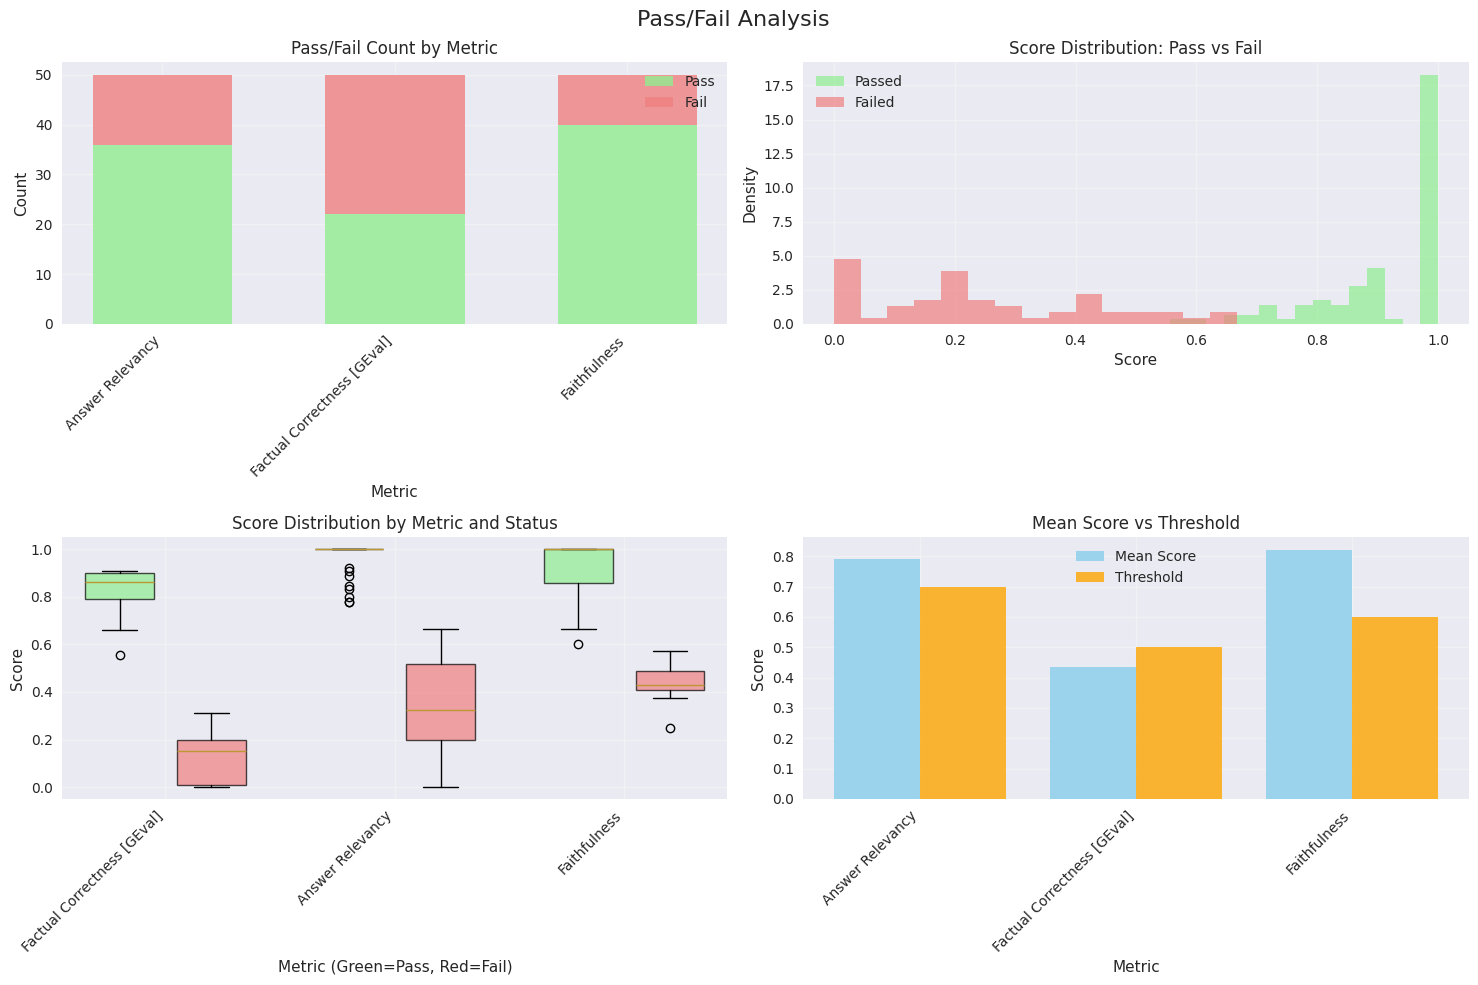

In [9]:
# Pass/Fail comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Pass/Fail Analysis', fontsize=16)

# 1. Success rate by metric (pie chart style)
success_counts = df.groupby('metric_name')['success'].agg(['sum', 'count']).reset_index()
success_counts['fail_count'] = success_counts['count'] - success_counts['sum']

x = np.arange(len(success_counts))
width = 0.6

axes[0,0].bar(x, success_counts['sum'], width, label='Pass', color='lightgreen', alpha=0.8)
axes[0,0].bar(x, success_counts['fail_count'], width, bottom=success_counts['sum'], 
              label='Fail', color='lightcoral', alpha=0.8)

axes[0,0].set_xlabel('Metric')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Pass/Fail Count by Metric')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(success_counts['metric_name'], rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Score distribution for passes vs fails
passed_scores = df[df['success']]['score']
failed_scores = df[~df['success']]['score']

axes[0,1].hist(passed_scores, bins=15, alpha=0.7, label='Passed', color='lightgreen', density=True)
axes[0,1].hist(failed_scores, bins=15, alpha=0.7, label='Failed', color='lightcoral', density=True)
axes[0,1].set_xlabel('Score')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Score Distribution: Pass vs Fail')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Box plot of scores by success status for each metric
for i, metric in enumerate(df['metric_name'].unique()):
    metric_data = df[df['metric_name'] == metric]
    passed = metric_data[metric_data['success']]['score']
    failed = metric_data[~metric_data['success']]['score']
    
    positions = [i*2, i*2+0.8]
    
    if len(passed) > 0:
        axes[1,0].boxplot(passed, positions=[positions[0]], widths=0.6, 
                         patch_artist=True, boxprops=dict(facecolor='lightgreen', alpha=0.7))
    if len(failed) > 0:
        axes[1,0].boxplot(failed, positions=[positions[1]], widths=0.6,
                         patch_artist=True, boxprops=dict(facecolor='lightcoral', alpha=0.7))

axes[1,0].set_xlabel('Metric (Green=Pass, Red=Fail)')
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('Score Distribution by Metric and Status')
axes[1,0].set_xticks([i*2+0.4 for i in range(len(df['metric_name'].unique()))])
axes[1,0].set_xticklabels(df['metric_name'].unique(), rotation=45, ha='right')
axes[1,0].grid(True, alpha=0.3)

# 4. Threshold analysis
threshold_analysis = df.groupby('metric_name').agg({
    'score': ['mean', 'std'],
    'threshold': 'first',
    'success': 'mean'
}).round(3)

threshold_analysis.columns = ['Mean_Score', 'Score_Std', 'Threshold', 'Success_Rate']
threshold_analysis = threshold_analysis.reset_index()

x = np.arange(len(threshold_analysis))
axes[1,1].bar(x - 0.2, threshold_analysis['Mean_Score'], 0.4, label='Mean Score', 
              color='skyblue', alpha=0.8)
axes[1,1].bar(x + 0.2, threshold_analysis['Threshold'], 0.4, label='Threshold', 
              color='orange', alpha=0.8)

axes[1,1].set_xlabel('Metric')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Mean Score vs Threshold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(threshold_analysis['metric_name'], rotation=45, ha='right')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Failed Test Cases Analysis

In [10]:
# Analyze failed test cases
failed_cases = df[~df['success']].copy()

if len(failed_cases) > 0:
    print("=== FAILED TEST CASES ANALYSIS ===")
    print(f"Total failed evaluations: {len(failed_cases)}")
    
    # Failed cases by metric
    print("\nFailed cases by metric:")
    failed_by_metric = failed_cases['metric_name'].value_counts()
    for metric, count in failed_by_metric.items():
        total_for_metric = len(df[df['metric_name'] == metric])
        print(f"  {metric}: {count} ({count/total_for_metric:.1%})")
    
    # Show some example failures with reasons
    print("\n=== EXAMPLE FAILURES ===")
    for metric in failed_cases['metric_name'].unique():
        metric_failures = failed_cases[failed_cases['metric_name'] == metric]
        print(f"\n📍 {metric} (showing first 2 failures):")
        
        for idx, (_, row) in enumerate(metric_failures.head(2).iterrows()):
            print(f"\n  Failure {idx + 1}:")
            print(f"    Score: {row['score']:.3f} (threshold: {row['threshold']:.3f})")
            print(f"    Input: {row['input'][:100]}...")
            if row['reason']:
                print(f"    Reason: {row['reason'][:200]}...")
else:
    print("🎉 No failed test cases found!")

=== FAILED TEST CASES ANALYSIS ===
Total failed evaluations: 52

Failed cases by metric:
  Factual Correctness [GEval]: 28 (56.0%)
  Answer Relevancy: 14 (28.0%)
  Faithfulness: 10 (20.0%)

=== EXAMPLE FAILURES ===

📍 Factual Correctness [GEval] (showing first 2 failures):

  Failure 1:
    Score: 0.144 (threshold: 0.500)
    Input: Jakie wydarzenia jazzowe odbywają się latem 2025 w Warszawie?...
    Reason: The actual output's title does not match or include the expected title 'Warsaw Summer Jazz Days 2025'. The date in the actual output is July 5, 2025, which does not match the expected date range from ...

  Failure 2:
    Score: 0.156 (threshold: 0.500)
    Input: Jakie są wydarzenia teatralne z elementami przyrodniczymi w Warszawie latem 2025?...
    Reason: The actual event title does not contain the expected title, failing the title comparison. The event dates differ significantly, with actual on July 5 and expected on July 19, violating the exact date ...

📍 Answer Relevancy (s

## 7. Interactive Scatter Plot

In [11]:
# Create an interactive scatter plot
# Create size column with minimum size for visibility
df_plot = df.copy()
df_plot['size_for_plot'] = np.maximum(df_plot['evaluation_cost'], 5)  # Minimum size of 5

# Convert boolean to string for better legend display
df_plot['success_str'] = df_plot['success'].map({True: 'Pass', False: 'Fail'})

fig = px.scatter(
    df_plot, 
    x='threshold', 
    y='score',
    color='metric_name',
    symbol='success_str',
    size='size_for_plot',
    hover_data=['success', 'evaluation_cost'],
    hover_name='metric_name',
    title='Interactive Evaluation Results: Score vs Threshold',
    labels={
        'threshold': 'Threshold',
        'score': 'Score',
        'metric_name': 'Metric',
        'success_str': 'Result',
        'evaluation_cost': 'Evaluation Cost'
    }
)

# Calculate proper bounds for diagonal line
threshold_min, threshold_max = df['threshold'].min(), df['threshold'].max()
score_min, score_max = df['score'].min(), df['score'].max()

# Use the overlapping range for the diagonal line
line_min = max(threshold_min, score_min)
line_max = min(threshold_max, score_max)

# Only add diagonal line if there's a meaningful range
if line_min < line_max:
    fig.add_shape(
        type="line",
        x0=line_min, y0=line_min,
        x1=line_max, y1=line_max,
        line=dict(color="red", width=2, dash="dash"),
        name="Score = Threshold"
    )

# Update layout for better interactivity
fig.update_layout(
    height=600,
    title_x=0.5,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    )
)

# Update traces to ensure they're toggleable
fig.update_traces(
    marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

fig.show()

# Create an additional detailed interactive plot
print("\n" + "="*50)
print("DETAILED INTERACTIVE ANALYSIS")
print("="*50)

# Create subplots for each metric
fig2 = make_subplots(
    rows=1, cols=len(df['metric_name'].unique()),
    subplot_titles=df['metric_name'].unique(),
    shared_yaxes=True
)

colors = px.colors.qualitative.Set1
for i, metric in enumerate(df['metric_name'].unique()):
    metric_data = df[df['metric_name'] == metric]
    
    # Add scatter points for passes
    passes = metric_data[metric_data['success']]
    if len(passes) > 0:
        fig2.add_trace(
            go.Scatter(
                x=passes['threshold'],
                y=passes['score'],
                mode='markers',
                name=f'{metric} - Pass',
                marker=dict(
                    color=colors[i % len(colors)],
                    size=10,
                    symbol='circle',
                    line=dict(width=2, color='darkgreen')
                ),
                hovertemplate=f'<b>{metric} - PASS</b><br>' +
                             'Score: %{y:.3f}<br>' +
                             'Threshold: %{x:.3f}<br>' +
                             '<extra></extra>'
            ),
            row=1, col=i+1
        )
    
    # Add scatter points for failures
    failures = metric_data[~metric_data['success']]
    if len(failures) > 0:
        fig2.add_trace(
            go.Scatter(
                x=failures['threshold'],
                y=failures['score'],
                mode='markers',
                name=f'{metric} - Fail',
                marker=dict(
                    color=colors[i % len(colors)],
                    size=10,
                    symbol='x',
                    line=dict(width=2, color='darkred')
                ),
                hovertemplate=f'<b>{metric} - FAIL</b><br>' +
                             'Score: %{y:.3f}<br>' +
                             'Threshold: %{x:.3f}<br>' +
                             '<extra></extra>'
            ),
            row=1, col=i+1
        )
    
    # Add threshold line for each subplot
    threshold_val = metric_data['threshold'].iloc[0]
    fig2.add_hline(
        y=threshold_val,
        line_dash="dash",
        line_color="red",
        annotation_text=f"Threshold: {threshold_val:.3f}",
        row=1, col=i+1
    )

fig2.update_layout(
    height=500,
    title_text="Detailed Analysis by Metric (Circle=Pass, X=Fail)",
    title_x=0.5,
    showlegend=True
)

fig2.update_xaxes(title_text="Threshold")
fig2.update_yaxes(title_text="Score", col=1)

fig2.show()


DETAILED INTERACTIVE ANALYSIS


## 8. Export Summary

In [12]:
# Create a summary report
summary_stats = df.groupby('metric_name').agg({
    'score': ['count', 'mean', 'std', 'min', 'max'],
    'success': ['sum', 'mean'],
    'threshold': 'first',
    'evaluation_cost': 'sum'
}).round(3)

summary_stats.columns = ['Count', 'Mean_Score', 'Score_Std', 'Min_Score', 'Max_Score', 
                        'Passed_Count', 'Success_Rate', 'Threshold', 'Total_Cost']

print("=== EVALUATION SUMMARY REPORT ===")
print(summary_stats)

# Extract run identifier from file path with better error handling
print(f"Debug - file_path: {file_path}")
print(f"Debug - file_path.parent: {file_path.parent}")
print(f"Debug - file_path.parent.name: {file_path.parent.name}")

# Extract run identifier - handle both relative and absolute paths
if file_path.parent.name.startswith('run_'):
    run_id = file_path.parent.name  # e.g., "run_20250717_2103"
else:
    # Fallback: extract from filename
    run_id = file_path.stem.replace('.deepeval-cache_', '').replace('-', '_')

print(f"Debug - extracted run_id: {run_id}")

# Create output directory
output_dir = Path("evaluation_results")
output_dir.mkdir(exist_ok=True)
print(f"Debug - output_dir: {output_dir.absolute()}")

# Save summary to CSV with run identifier
summary_filename = f"deepeval_summary_{run_id}.csv"
summary_path = output_dir / summary_filename
summary_stats.to_csv(summary_path)
print(f"\n📊 Summary saved to '{summary_path.absolute()}'")

# Save detailed data to CSV with run identifier  
detailed_filename = f"deepeval_detailed_results_{run_id}.csv"
detailed_path = output_dir / detailed_filename
df.to_csv(detailed_path, index=False)
print(f"📋 Detailed results saved to '{detailed_path.absolute()}'")

# Also save a metadata file with run information
metadata = {
    'run_id': run_id,
    'source_file': str(file_path.absolute()),
    'total_test_cases': len(df['input'].unique()),
    'total_evaluations': len(df),
    'metrics': list(df['metric_name'].unique()),
    'evaluation_date': run_id.split('_')[-2:] if '_' in run_id else [run_id], 
    'overall_success_rate': float(df['success'].mean())  # Ensure JSON serializable
}

metadata_filename = f"deepeval_metadata_{run_id}.json"
metadata_path = output_dir / metadata_filename
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"📄 Metadata saved to '{metadata_path.absolute()}'")

print(f"\n📁 All files saved in directory: {output_dir.absolute()}")
print(f"Files created:")
print(f"  - {summary_filename}")
print(f"  - {detailed_filename}") 
print(f"  - {metadata_filename}")

=== EVALUATION SUMMARY REPORT ===
                             Count  Mean_Score  Score_Std  Min_Score  \
metric_name                                                            
Answer Relevancy                50       0.790      0.313       0.00   
Factual Correctness [GEval]     50       0.435      0.361       0.00   
Faithfulness                    50       0.821      0.227       0.25   

                             Max_Score  Passed_Count  Success_Rate  Threshold  \
metric_name                                                                     
Answer Relevancy                 1.000            36          0.72        0.7   
Factual Correctness [GEval]      0.908            22          0.44        0.5   
Faithfulness                     1.000            40          0.80        0.6   

                             Total_Cost  
metric_name                              
Answer Relevancy                      0  
Factual Correctness [GEval]           0  
Faithfulness                   

## 🔄 Two-Run Comparison Analysis

This section appears when you have configured both `file1` and `file2`. It provides comprehensive side-by-side comparison between your two evaluation runs.

# Display data loading summary

In [13]:

if df is not None or multi_run_df is not None:
    print("📊 Data loading completed successfully!")
    
    if comparison_mode and multi_run_df is not None:
        print(f"🔄 Comparison mode active")
        print(f"📈 Run 1 ({run1_id}): {len(multi_run_df[multi_run_df['run_id'] == run1_id])} evaluations")
        print(f"📈 Run 2 ({run2_id}): {len(multi_run_df[multi_run_df['run_id'] == run2_id])} evaluations")
        print(f"🎯 Metrics: {list(multi_run_df['metric_name'].unique())}")
    else:
        print(f"📊 Single-run analysis for: {run_id}")
        print(f"📈 Total evaluations: {len(df)}")
        print(f"🎯 Metrics: {list(df['metric_name'].unique())}")
        
        # Display basic statistics for single run
        print("\n=== EVALUATION SUMMARY ===")
        print(f"Total test cases: {len(df['input'].unique())}")
        print(f"Total metric evaluations: {len(df)}")
        print("\nMetrics distribution:")
        print(df['metric_name'].value_counts())
        print("\nSuccess rate by metric:")
        success_rates = df.groupby('metric_name')['success'].agg(['count', 'sum', 'mean']).round(3)
        success_rates.columns = ['Total', 'Passed', 'Success_Rate']
        print(success_rates)
else:
    print("❌ No data could be loaded. Please check your file paths in the configuration section.")

📊 Data loading completed successfully!
🔄 Comparison mode active
📈 Run 1 (run_20250717_2103): 150 evaluations
📈 Run 2 (run_20250723_1409): 30 evaluations
🎯 Metrics: ['Factual Correctness [GEval]', 'Answer Relevancy', 'Faithfulness']


In [14]:
### 9.1 Side-by-Side Comparison Dashboard

# Create comparison dashboard (only runs in comparison mode)

In [15]:

if comparison_mode and multi_run_df is not None and len(multi_run_df['run_id'].unique()) == 2:
    
    print("🎯 Creating side-by-side comparison dashboard...")
    
    # Calculate summary statistics for both runs
    comparison_summary = multi_run_df.groupby(['run_id', 'metric_name']).agg({
        'score': ['mean', 'std', 'count'],
        'success': ['mean', 'sum'],
        'threshold': 'first'
    }).round(3)
    
    comparison_summary.columns = ['Mean_Score', 'Score_Std', 'Count', 'Success_Rate', 'Total_Success', 'Threshold']
    comparison_summary = comparison_summary.reset_index()
    
    # Display comparison table
    print("\n" + "="*60)
    print("SIDE-BY-SIDE COMPARISON SUMMARY")
    print("="*60)
    
    comparison_pivot = comparison_summary.pivot(index='metric_name', columns='run_id', values=['Mean_Score', 'Success_Rate'])
    print("\n📊 Mean Scores:")
    print(comparison_pivot['Mean_Score'].round(3))
    print("\n🎯 Success Rates:")
    print(comparison_pivot['Success_Rate'].round(3))
    
    # Create comprehensive comparison visualizations
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            f'Score Comparison: {run1_id} vs {run2_id}',
            f'Success Rate Comparison', 
            f'Score Distributions',
            f'Improvement Analysis'
        ),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "box"}, {"type": "bar"}]]
    )
    
    metrics = multi_run_df['metric_name'].unique()
    colors = ['#1f77b4', '#ff7f0e']  # Blue for run1, Orange for run2
    
    # 1. Score comparison bar chart
    for i, run_id_current in enumerate([run1_id, run2_id]):
        run_summary = comparison_summary[comparison_summary['run_id'] == run_id_current]
        
        fig.add_trace(
            go.Bar(
                x=run_summary['metric_name'],
                y=run_summary['Mean_Score'],
                name=f'{run_id_current}',
                marker_color=colors[i],
                error_y=dict(type='data', array=run_summary['Score_Std']),
                text=[f"{val:.3f}" for val in run_summary['Mean_Score']],
                textposition='auto'
            ),
            row=1, col=1
        )
    
    # 2. Success rate comparison
    for i, run_id_current in enumerate([run1_id, run2_id]):
        run_summary = comparison_summary[comparison_summary['run_id'] == run_id_current]
        
        fig.add_trace(
            go.Bar(
                x=run_summary['metric_name'],
                y=run_summary['Success_Rate'],
                name=f'{run_id_current} Success',
                marker_color=colors[i],
                opacity=0.7,
                text=[f"{val:.1%}" for val in run_summary['Success_Rate']],
                textposition='auto'
            ),
            row=1, col=2
        )
    
    # 3. Box plots for score distributions
    for i, run_id_current in enumerate([run1_id, run2_id]):
        run_data = multi_run_df[multi_run_df['run_id'] == run_id_current]
        
        fig.add_trace(
            go.Box(
                y=run_data['score'],
                name=run_id_current,
                marker_color=colors[i],
                boxpoints='outliers'
            ),
            row=2, col=1
        )
    
    # 4. Improvement analysis (difference between runs)
    improvement_data = []
    run1_summary = comparison_summary[comparison_summary['run_id'] == run1_id]
    run2_summary = comparison_summary[comparison_summary['run_id'] == run2_id]
    
    for metric in metrics:
        run1_score = run1_summary[run1_summary['metric_name'] == metric]['Mean_Score'].iloc[0]
        run2_score = run2_summary[run2_summary['metric_name'] == metric]['Mean_Score'].iloc[0]
        improvement = ((run2_score - run1_score) / run1_score * 100) if run1_score != 0 else 0
        
        improvement_data.append({
            'metric': metric,
            'improvement': improvement,
            'run1_score': run1_score,
            'run2_score': run2_score
        })
    
    improvement_df = pd.DataFrame(improvement_data)
    
    fig.add_trace(
        go.Bar(
            x=improvement_df['metric'],
            y=improvement_df['improvement'],
            name='Improvement %',
            marker_color=['green' if x > 0 else 'red' for x in improvement_df['improvement']],
            text=[f"{val:+.1f}%" for val in improvement_df['improvement']],
            textposition='auto'
        ),
        row=2, col=2
    )
    
    # Update layout
    fig.update_layout(
        height=800,
        title_text=f"Comprehensive Comparison: {run1_id} vs {run2_id}",
        title_x=0.5,
        showlegend=True
    )
    
    # Update axes labels
    fig.update_xaxes(title_text="Metric", row=1, col=1)
    fig.update_yaxes(title_text="Mean Score", row=1, col=1)
    
    fig.update_xaxes(title_text="Metric", row=1, col=2)
    fig.update_yaxes(title_text="Success Rate", row=1, col=2)
    
    fig.update_xaxes(title_text="Run", row=2, col=1)
    fig.update_yaxes(title_text="Score", row=2, col=1)
    
    fig.update_xaxes(title_text="Metric", row=2, col=2)
    fig.update_yaxes(title_text="Improvement (%)", row=2, col=2)
    
    fig.show()
    
    # Print detailed improvement analysis
    print(f"\n📈 DETAILED IMPROVEMENT ANALYSIS ({run2_id} vs {run1_id}):")
    for _, row in improvement_df.iterrows():
        if row['improvement'] > 0:
            status = f"📈 IMPROVED by {row['improvement']:.1f}%"
        elif row['improvement'] < 0:
            status = f"📉 DECLINED by {abs(row['improvement']):.1f}%"
        else:
            status = f"➡️  NO CHANGE"
        
        print(f"  {row['metric']}: {status}")
        print(f"    {run1_id}: {row['run1_score']:.3f} → {run2_id}: {row['run2_score']:.3f}")
    
    # Statistical significance test
    print(f"\n🔬 STATISTICAL SIGNIFICANCE TESTS:")
    try:
        from scipy import stats
        
        for metric in metrics:
            run1_scores = multi_run_df[(multi_run_df['run_id'] == run1_id) & 
                                       (multi_run_df['metric_name'] == metric)]['score'].values
            run2_scores = multi_run_df[(multi_run_df['run_id'] == run2_id) & 
                                       (multi_run_df['metric_name'] == metric)]['score'].values
            
            if len(run1_scores) > 1 and len(run2_scores) > 1:
                try:
                    t_stat, p_value = stats.ttest_ind(run1_scores, run2_scores)
                    significance = "🔴 Significant" if p_value < 0.05 else "🟢 Not significant"
                    print(f"  {metric}: t-stat={t_stat:.3f}, p-value={p_value:.4f} - {significance}")
                except:
                    print(f"  {metric}: Could not perform t-test")
            else:
                print(f"  {metric}: Insufficient data for statistical test")
    except ImportError:
        print("  ⚠️  scipy not available for statistical tests")

elif comparison_mode:
    print("⚠️ Comparison mode is enabled but data loading failed.")
    print("💡 Please check your file2 path in the configuration section.")
else:
    print("ℹ️ Comparison analysis skipped - only one file configured.")
    print("💡 To enable comparison, set both file1 and file2 in the configuration section.")

🎯 Creating side-by-side comparison dashboard...

SIDE-BY-SIDE COMPARISON SUMMARY

📊 Mean Scores:
run_id                       run_20250717_2103  run_20250723_1409
metric_name                                                      
Answer Relevancy                         0.790              0.870
Factual Correctness [GEval]              0.435              0.710
Faithfulness                             0.821              0.834

🎯 Success Rates:
run_id                       run_20250717_2103  run_20250723_1409
metric_name                                                      
Answer Relevancy                          0.72                0.9
Factual Correctness [GEval]               0.44                0.8
Faithfulness                              0.80                0.7



📈 DETAILED IMPROVEMENT ANALYSIS (run_20250723_1409 vs run_20250717_2103):
  Factual Correctness [GEval]: 📈 IMPROVED by 63.2%
    run_20250717_2103: 0.435 → run_20250723_1409: 0.710
  Answer Relevancy: 📈 IMPROVED by 10.1%
    run_20250717_2103: 0.790 → run_20250723_1409: 0.870
  Faithfulness: 📈 IMPROVED by 1.6%
    run_20250717_2103: 0.821 → run_20250723_1409: 0.834

🔬 STATISTICAL SIGNIFICANCE TESTS:
  ⚠️  scipy not available for statistical tests


### 9.2 Export Comparison Results
# Export comparison results

In [16]:

if 'multi_run_df' in locals() and len(multi_run_df['run_id'].unique()) == 2:
    
    # Create timestamp for export
    export_timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    
    # Create comparison output directory
    comparison_output_dir = Path("evaluation_results/comparison_analysis")
    comparison_output_dir.mkdir(parents=True, exist_ok=True)
    
    print("💾 Exporting Comparison Analysis Results...")
    
    # 1. Export combined comparison data
    comparison_filename = f"comparison_data_{run1_id}_vs_{run2_id}_{export_timestamp}.csv"
    # Clean filename by removing invalid characters
    comparison_filename = comparison_filename.replace(" ", "_").replace("/", "_").replace("\\", "_")
    comparison_path = comparison_output_dir / comparison_filename
    multi_run_df.to_csv(comparison_path, index=False)
    print(f"📋 Combined comparison data saved to '{comparison_path}'")
    
    # 2. Export summary comparison table
    summary_comparison = multi_run_df.groupby(['run_id', 'metric_name']).agg({
        'score': ['count', 'mean', 'std', 'min', 'max'],
        'success': ['mean', 'sum'],
        'threshold': 'first'
    }).round(3)
    
    summary_comparison.columns = ['Count', 'Mean_Score', 'Score_Std', 'Min_Score', 'Max_Score', 
                                 'Success_Rate', 'Total_Success', 'Threshold']
    summary_comparison = summary_comparison.reset_index()
    
    summary_filename = f"comparison_summary_{run1_id}_vs_{run2_id}_{export_timestamp}.csv"
    summary_filename = summary_filename.replace(" ", "_").replace("/", "_").replace("\\", "_")
    summary_path = comparison_output_dir / summary_filename
    summary_comparison.to_csv(summary_path, index=False)
    print(f"📊 Comparison summary saved to '{comparison_path}'")
    
    # 3. Export improvement analysis
    if 'improvement_df' in locals():
        improvement_filename = f"improvement_analysis_{run1_id}_vs_{run2_id}_{export_timestamp}.csv"
        improvement_filename = improvement_filename.replace(" ", "_").replace("/", "_").replace("\\", "_")
        improvement_path = comparison_output_dir / improvement_filename
        improvement_df.to_csv(improvement_path, index=False)
        print(f"📈 Improvement analysis saved to '{improvement_path}'")
    
    # 4. Export comparison metadata
    comparison_metadata = {
        'export_timestamp': export_timestamp,
        'run1': {
            'name': run1_id,
            'file_path': file1,
            'total_evaluations': len(multi_run_df[multi_run_df['run_id'] == run1_id])
        },
        'run2': {
            'name': run2_id,
            'file_path': file2,
            'total_evaluations': len(multi_run_df[multi_run_df['run_id'] == run2_id])
        },
        'metrics_compared': list(multi_run_df['metric_name'].unique()),
        'overall_statistics': {
            'run1_mean_score': float(multi_run_df[multi_run_df['run_id'] == run1_id]['score'].mean()),
            'run2_mean_score': float(multi_run_df[multi_run_df['run_id'] == run2_id]['score'].mean()),
            'run1_success_rate': float(multi_run_df[multi_run_df['run_id'] == run1_id]['success'].mean()),
            'run2_success_rate': float(multi_run_df[multi_run_df['run_id'] == run2_id]['success'].mean())
        }
    }
    
    metadata_filename = f"comparison_metadata_{run1_id}_vs_{run2_id}_{export_timestamp}.json"
    metadata_filename = metadata_filename.replace(" ", "_").replace("/", "_").replace("\\", "_")
    metadata_path = comparison_output_dir / metadata_filename
    with open(metadata_path, 'w') as f:
        json.dump(comparison_metadata, f, indent=2, default=str)
    print(f"📄 Comparison metadata saved to '{metadata_path}'")
    
    print(f"\n📁 All comparison files saved in: {comparison_output_dir.absolute()}")
    print("\\nFiles created:")
    print(f"  - {comparison_filename} (raw comparison data)")
    print(f"  - {summary_filename} (summary statistics)")
    if 'improvement_df' in locals():
        print(f"  - {improvement_filename} (improvement analysis)")
    print(f"  - {metadata_filename} (comparison metadata)")
    
    print(f"\n🎯 QUICK SUMMARY:")
    run1_mean = multi_run_df[multi_run_df['run_id'] == run1_id]['score'].mean()
    run2_mean = multi_run_df[multi_run_df['run_id'] == run2_id]['score'].mean()
    overall_improvement = ((run2_mean - run1_mean) / run1_mean * 100) if run1_mean != 0 else 0
    
    print(f"  {run1_id}: {run1_mean:.3f} average score")
    print(f"  {run2_id}: {run2_mean:.3f} average score")
    
    if overall_improvement > 0:
        print(f"  📈 Overall improvement: +{overall_improvement:.1f}%")
    elif overall_improvement < 0:
        print(f"  📉 Overall decline: {overall_improvement:.1f}%")
    else:
        print(f"  ➡️  No overall change")

else:
    print("❌ Comparison export requires exactly 2 runs to be loaded.")
    if 'multi_run_df' not in locals():
        print("💡 Please run the file loading cell above first.")
    else:
        print(f"💡 Currently loaded: {len(multi_run_df['run_id'].unique())} runs")

💾 Exporting Comparison Analysis Results...
📋 Combined comparison data saved to 'evaluation_results/comparison_analysis/comparison_data_run_20250717_2103_vs_run_20250723_1409_20250724_1110.csv'
📊 Comparison summary saved to 'evaluation_results/comparison_analysis/comparison_data_run_20250717_2103_vs_run_20250723_1409_20250724_1110.csv'
📈 Improvement analysis saved to 'evaluation_results/comparison_analysis/improvement_analysis_run_20250717_2103_vs_run_20250723_1409_20250724_1110.csv'
📄 Comparison metadata saved to 'evaluation_results/comparison_analysis/comparison_metadata_run_20250717_2103_vs_run_20250723_1409_20250724_1110.json'

📁 All comparison files saved in: /home/michal/projects/maven/my_ai_agent/evaluation_results/comparison_analysis
\nFiles created:
  - comparison_data_run_20250717_2103_vs_run_20250723_1409_20250724_1110.csv (raw comparison data)
  - comparison_summary_run_20250717_2103_vs_run_20250723_1409_20250724_1110.csv (summary statistics)
  - improvement_analysis_run_202

In [17]:
# Multi-run comparison dashboard using the loaded comparison data
if comparison_mode and 'multi_run_df' in locals() and len(multi_run_df['run_id'].unique()) >= 2:
    
    print("🎯 Creating multi-run comparison dashboard using your configured files...")
    
    # Calculate summary statistics by run and metric
    run_summary = multi_run_df.groupby(['run_id', 'metric_name']).agg({
        'score': ['mean', 'std', 'count'],
        'success': ['mean', 'sum'],
        'threshold': 'first'
    }).round(3)
    
    run_summary.columns = ['Mean_Score', 'Score_Std', 'Count', 'Success_Rate', 'Total_Success', 'Threshold']
    run_summary = run_summary.reset_index()
    
    print("=== MULTI-RUN COMPARISON SUMMARY ===")
    print(run_summary.pivot(index='metric_name', columns='run_id', values='Mean_Score'))
    
    # Create subplots for comprehensive comparison
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Score Trends by Run',
            'Success Rate Comparison', 
            'Score Distribution by Run',
            'Performance vs Threshold'
        ),
        specs=[[{"secondary_y": False}, {"type": "bar"}],
               [{"type": "box"}, {"type": "scatter"}]]
    )
    
    # 1. Score trends over time (line plot)
    metrics = multi_run_df['metric_name'].unique()
    colors = px.colors.qualitative.Set1
    
    for i, metric in enumerate(metrics):
        metric_summary = run_summary[run_summary['metric_name'] == metric].sort_values('run_id')
        
        fig.add_trace(
            go.Scatter(
                x=metric_summary['run_id'],
                y=metric_summary['Mean_Score'],
                mode='lines+markers',
                name=f'{metric}',
                line=dict(color=colors[i % len(colors)], width=3),
                marker=dict(size=8),
                error_y=dict(
                    type='data',
                    array=metric_summary['Score_Std'],
                    visible=True
                )
            ),
            row=1, col=1
        )
    
    # 2. Success rate comparison (bar chart)
    for i, metric in enumerate(metrics):
        metric_summary = run_summary[run_summary['metric_name'] == metric]
        
        fig.add_trace(
            go.Bar(
                x=metric_summary['run_id'],
                y=metric_summary['Success_Rate'],
                name=f'{metric} Success',
                marker_color=colors[i % len(colors)],
                opacity=0.7,
                text=[f"{val:.1%}" for val in metric_summary['Success_Rate']],
                textposition='auto'
            ),
            row=1, col=2
        )
    
    # 3. Box plot of score distributions by run
    for run_id_item in multi_run_df['run_id'].unique():
        run_data = multi_run_df[multi_run_df['run_id'] == run_id_item]
        
        fig.add_trace(
            go.Box(
                y=run_data['score'],
                name=run_id_item,
                boxpoints='outliers'
            ),
            row=2, col=1
        )
    
    # 4. Scatter plot: score vs threshold by run
    for i, run_id_item in enumerate(multi_run_df['run_id'].unique()):
        run_data = multi_run_df[multi_run_df['run_id'] == run_id_item]
        
        fig.add_trace(
            go.Scatter(
                x=run_data['threshold'],
                y=run_data['score'],
                mode='markers',
                name=f'{run_id_item}',
                marker=dict(
                    size=6,
                    opacity=0.7,
                    symbol=['circle' if success else 'x' for success in run_data['success']]
                ),
                hovertemplate=f'<b>{run_id_item}</b><br>' +
                             'Score: %{y:.3f}<br>' +
                             'Threshold: %{x:.3f}<br>' +
                             '<extra></extra>'
            ),
            row=2, col=2
        )
    
    # Update layout
    fig.update_layout(
        height=800,
        title_text=f"Multi-Run Comparison Dashboard: {' vs '.join(multi_run_df['run_id'].unique())}",
        title_x=0.5,
        showlegend=True
    )
    
    # Update axes
    fig.update_xaxes(title_text="Run ID", row=1, col=1)
    fig.update_yaxes(title_text="Mean Score", row=1, col=1)
    
    fig.update_xaxes(title_text="Run ID", row=1, col=2)
    fig.update_yaxes(title_text="Success Rate", row=1, col=2)
    
    fig.update_xaxes(title_text="Run ID", row=2, col=1)
    fig.update_yaxes(title_text="Score", row=2, col=1)
    
    fig.update_xaxes(title_text="Threshold", row=2, col=2)
    fig.update_yaxes(title_text="Score", row=2, col=2)
    
    fig.show()
    
    # Performance improvement summary
    if len(multi_run_df['run_id'].unique()) == 2:
        runs = sorted(multi_run_df['run_id'].unique())
        print(f"\n📈 PERFORMANCE CHANGES ({runs[1]} vs {runs[0]}):")
        
        for metric in metrics:
            run1_score = run_summary[(run_summary['run_id'] == runs[0]) & 
                                   (run_summary['metric_name'] == metric)]['Mean_Score'].iloc[0]
            run2_score = run_summary[(run_summary['run_id'] == runs[1]) & 
                                   (run_summary['metric_name'] == metric)]['Mean_Score'].iloc[0]
            
            change = ((run2_score - run1_score) / run1_score * 100) if run1_score != 0 else 0
            
            if change > 0:
                direction = f"📈 IMPROVED by {change:.1f}%"
            elif change < 0:
                direction = f"📉 DECLINED by {abs(change):.1f}%"
            else:
                direction = "➡️ NO CHANGE"
            
            print(f"  {metric}: {direction}")
            print(f"    {runs[0]}: {run1_score:.3f} → {runs[1]}: {run2_score:.3f}")

else:
    if not comparison_mode:
        print("ℹ️ Multi-run comparison requires multiple files to be configured.")
        print("💡 Set both file1 and file2 in the configuration section to enable comparison.")
    else:
        print("❌ Multi-run comparison data not available.")
        print("💡 Please check that both files were loaded successfully above.")

🎯 Creating multi-run comparison dashboard using your configured files...
=== MULTI-RUN COMPARISON SUMMARY ===
run_id                       run_20250717_2103  run_20250723_1409
metric_name                                                      
Answer Relevancy                         0.790              0.870
Factual Correctness [GEval]              0.435              0.710
Faithfulness                             0.821              0.834



📈 PERFORMANCE CHANGES (run_20250723_1409 vs run_20250717_2103):
  Factual Correctness [GEval]: 📈 IMPROVED by 63.2%
    run_20250717_2103: 0.435 → run_20250723_1409: 0.710
  Answer Relevancy: 📈 IMPROVED by 10.1%
    run_20250717_2103: 0.790 → run_20250723_1409: 0.870
  Faithfulness: 📈 IMPROVED by 1.6%
    run_20250717_2103: 0.821 → run_20250723_1409: 0.834


### 9.1 Run Comparison Dashboard

In [18]:
# Optional: Advanced Multi-Run Discovery
# This section can discover and load multiple runs automatically from .deepeval directory
# Note: The main comparison above uses your configured file1 and file2

def find_all_evaluation_runs(base_path=".deepeval"):
    """Find all evaluation run directories and their cache files"""
    run_dirs = []
    base_path = Path(base_path)
    
    if not base_path.exists():
        return run_dirs
    
    # Look for run directories
    for item in base_path.iterdir():
        if item.is_dir() and item.name.startswith('run_'):
            # Look for cache files in this run directory (only .deepeval-cache files)
            cache_files = list(item.glob('.deepeval-cache*.json'))
            if cache_files:
                # Extract timestamp for sorting
                try:
                    parts = item.name.split('_')
                    if len(parts) >= 3:
                        date_part = parts[1]  # '20250717'
                        time_part = parts[2]  # '2103'
                        timestamp_str = f"{date_part[:4]}-{date_part[4:6]}-{date_part[6:8]} {time_part[:2]}:{time_part[2:4]}"
                    else:
                        timestamp_str = "Unknown time"
                except:
                    timestamp_str = "Unknown time"
                
                run_info = {
                    'run_id': item.name,
                    'run_path': item,
                    'cache_files': cache_files,
                    'timestamp_str': timestamp_str
                }
                run_dirs.append(run_info)
    
    # Sort by run_id (which includes timestamp)
    run_dirs.sort(key=lambda x: x['run_id'])
    return run_dirs

# Show available runs for reference
print("📁 AVAILABLE EVALUATION RUNS:")
print("="*50)

available_runs = find_all_evaluation_runs()

if available_runs:
    print(f"Found {len(available_runs)} evaluation runs in .deepeval directory:")
    print()
    
    for i, run in enumerate(available_runs, 1):
        print(f"{i:2d}. {run['run_id']}")
        print(f"     📅 Time: {run['timestamp_str']}")
        print(f"     📄 Files: {len(run['cache_files'])} cache file(s)")
        
        # Show file paths
        for cache_file in run['cache_files']:
            print(f"        - {cache_file.name}")
        print()
    
    print(f"💡 TO COMPARE DIFFERENT RUNS:")
    print(f"   1. Copy the desired file paths from above")
    print(f"   2. Update file1 and file2 in the configuration section (cell 1)")
    print(f"   3. Re-run the notebook")
    
    print(f"\n📊 CURRENTLY CONFIGURED:")
    if 'file1' in locals():
        print(f"   file1: {file1}")
    if 'file2' in locals():
        print(f"   file2: {file2}")
    
    if 'run1_id' in locals() and 'run2_id' in locals():
        print(f"\n🎯 ACTIVE COMPARISON: {run1_id} vs {run2_id}")
    elif 'run_id' in locals():
        print(f"\n📊 SINGLE RUN MODE: {run_id}")
    
else:
    print("❌ No evaluation runs found in .deepeval directory")
    print()
    print("💡 TROUBLESHOOTING:")
    print("   - Make sure you have run DeepEval evaluations first")
    print("   - Check that .deepeval directory exists in current folder")
    print("   - Ensure evaluation runs are saved in run_YYYYMMDD_HHMM format")

print("="*50)

📁 AVAILABLE EVALUATION RUNS:
Found 11 evaluation runs in .deepeval directory:

 1. run_20250717_2103
     📅 Time: 2025-07-17 21:03
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250717_2103.json

 2. run_20250720_2156
     📅 Time: 2025-07-20 21:56
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250720_2156.json

 3. run_20250721_0950
     📅 Time: 2025-07-21 09:50
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250721_0950.json

 4. run_20250721_1130
     📅 Time: 2025-07-21 11:30
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250721_1130.json

 5. run_20250721_1306
     📅 Time: 2025-07-21 13:06
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250721_1306.json

 6. run_20250721_1451
     📅 Time: 2025-07-21 14:51
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250721_1451.json

 7. run_20250721_1557
     📅 Time: 2025-07-21 15:57
     📄 Files: 1 cache file(s)
        - .deepeval-cache_20250721_1557.json

 8. run_20250721_1645
   